In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay,precision_recall_curve, average_precision_score, auc, roc_curve
from sklearn.inspection import permutation_importance
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\train_data.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv")

In [3]:
seq_cols = ["CDR1 aligned", "CDR2 aligned", "CDR3 aligned"]
amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
add_position = True

In [4]:
def concat_cdrs(row):
    return "".join(str(row[col]) for col in seq_cols)

train_df["CDRs"] = train_df.apply(concat_cdrs, axis=1)
val_df["CDRs"] = val_df.apply(concat_cdrs, axis=1)
train_lengths = train_df["CDRs"].str.len().iloc[0]
val_lengths = val_df["CDRs"].str.len().iloc[0]
test_df["CDRs"] = test_df.apply(concat_cdrs, axis=1)
test_lengths = test_df["CDRs"].str.len().iloc[0]

#assertions checking
assert train_lengths == val_lengths
assert (train_df["CDRs"].str.len() == train_lengths).all()
assert (val_df["CDRs"].str.len() == val_lengths).all()

In [5]:
# one-hot encoding (identity matrix)
aa2idx = {aa: i for i, aa in enumerate(amino_acids)}
I = np.eye(len(amino_acids),dtype=np.float32) # identity matrix

In [6]:
def one_hot_encode(seq, add_position=True):
    feats = []
    L = len(seq)
    for i, a in enumerate(seq):
        # 21-dim AA one-hot
        v = I[aa2idx.get(a, aa2idx["-"])]
        
        if add_position:
            # add normalized position → 22 dims
            v = np.concatenate((v, [i / L]))

        feats.append(v)

    return np.array(feats, dtype=np.float32)   # shape [L, D]


In [7]:
x_train = np.vstack([one_hot_encode(seq, add_position) for seq in train_df["CDRs"]])
y_train = train_df["Label"].values
x_val = np.vstack([one_hot_encode(seq, add_position) for seq in val_df["CDRs"]])
y_val = val_df["Label"].values
x_test = np.vstack([one_hot_encode(seq, add_position) for seq in test_df["CDRs"]])
y_test = test_df["Label"].values

In [8]:

def build_tensors(df):
    seqs = [torch.tensor(one_hot_encode(seq), dtype=torch.float32)
            for seq in df["CDRs"]]
    
    X = pad_sequence(seqs, batch_first=True)  # [B, Lmax, D]

    y = torch.tensor(df["Label"].values, dtype=torch.long)

    return X, y

x_train_tensor, y_train_tensor = build_tensors(train_df)
x_val_tensor, y_val_tensor     = build_tensors(val_df)
x_test_tensor, y_test_tensor   = build_tensors(test_df)

In [9]:

class ProteinCNN(nn.Module):
    def __init__(self, input_dim=22, num_classes=2):
        super().__init__()

        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: [B, L, D]
        x = x.permute(0, 2, 1)               # → [B, D, L]

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(x).squeeze(-1)         # [B, 256]
        x = self.dropout(x)
        x = F.relu(self.fc1(x))

        return self.fc2(x)                   # logits


In [10]:
# when creating label tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)


In [11]:
# Dataloaders 

batch_size = 32
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(x_val_tensor, y_val_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Model, Loss and optimizer
model = ProteinCNN(input_dim=x_train_tensor.shape[2]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)


In [12]:

# Training loop

num_epochs = 10
patience = 3
best_val_loss = float("inf")
bad_epochs = 0
history = []

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0
    train_preds = []
    train_labels = []

    for X_batch, y_batch in tqdm(train_dataloader):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(y_batch.detach().cpu().numpy())

    train_loss = running_loss / len(train_dataloader.dataset)
    train_f1 = f1_score(train_labels, train_preds, zero_division=0)
    print(f"\nEpoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}  | Train F1: {train_f1:.3f}")

    # -------- VALIDATION --------
    model.eval()
    val_probs = []
    all_preds = []
    all_labels = []

    val_running_loss = 0.0 

    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            probs = torch.softmax(logits, dim=1)[:,1]

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
    val_loss = val_running_loss / len(val_dataloader.dataset)
    scheduler.step(val_loss)

    accuracy  = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), "best_cdrs_cnn_model.pth")
    else:
        bad_epochs += 1

    history.append({
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "train_f1": float(train_f1),
        "val_f1": float(f1),
        "val_acc": float(accuracy),
    })

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Precision: {precision:.4f}")
    print(f"Validation Recall: {recall:.4f}")
    print(f"Validation F1-Score: {f1:.4f}")
    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val_loss={best_val_loss:.4f}")
        break

100%|██████████| 3085/3085 [00:44<00:00, 70.01it/s] 



Epoch 1/10, Training Loss: 0.6827  | Train F1: 0.571
Validation Loss: 0.6666
Validation Accuracy: 0.5938
Validation Precision: 0.6059
Validation Recall: 0.5510
Validation F1-Score: 0.5771


100%|██████████| 3085/3085 [00:28<00:00, 109.82it/s]



Epoch 2/10, Training Loss: 0.6700  | Train F1: 0.596
Validation Loss: 0.6639
Validation Accuracy: 0.5969
Validation Precision: 0.5858
Validation Recall: 0.6778
Validation F1-Score: 0.6285


100%|██████████| 3085/3085 [00:26<00:00, 115.38it/s]


...


Epoch 7/10, Training Loss: 0.6538  | Train F1: 0.622
Validation Loss: 0.6635
Validation Accuracy: 0.5967
Validation Precision: 0.5784
Validation Recall: 0.7312
Validation F1-Score: 0.6459


100%|██████████| 3085/3085 [00:33<00:00, 90.89it/s] 



Epoch 8/10, Training Loss: 0.6512  | Train F1: 0.624
Validation Loss: 0.6679
Validation Accuracy: 0.5940
Validation Precision: 0.6289
Validation Recall: 0.4707
Validation F1-Score: 0.5384


100%|██████████| 3085/3085 [00:33<00:00, 90.78it/s] 



Epoch 9/10, Training Loss: 0.6389  | Train F1: 0.641
Validation Loss: 0.6618
Validation Accuracy: 0.6059
Validation Precision: 0.6114
Validation Recall: 0.5943
Validation F1-Score: 0.6027
Early stopping at epoch 9. Best val_loss=0.6604


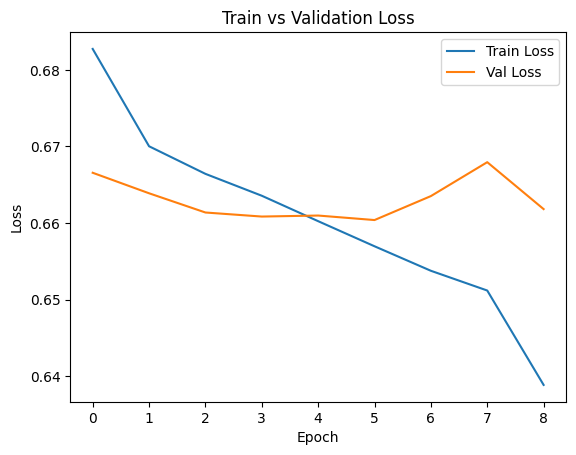

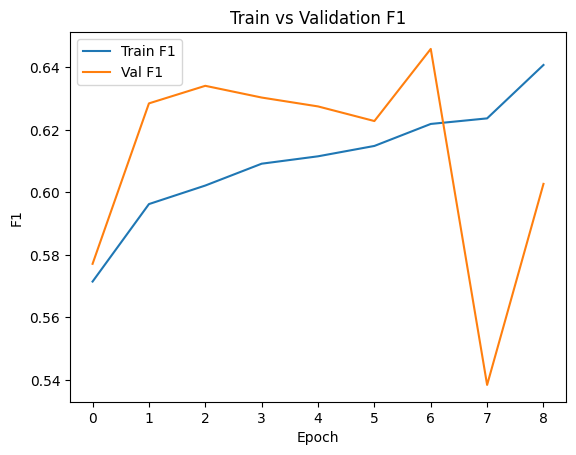

In [13]:
train_losses = [h["train_loss"] for h in history]
val_losses   = [h["val_loss"] for h in history]

plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()

train_f1 = [h["train_f1"] for h in history]
val_f1   = [h["val_f1"] for h in history]

plt.figure()
plt.plot(train_f1)
plt.plot(val_f1)
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Train vs Validation F1")
plt.legend(["Train F1", "Val F1"])
plt.show()


PR AUC (AUC over PR curve): 0.6456503733458241

Validation Average Precision (AP): 0.6458841997590922


<function matplotlib.pyplot.show(close=None, block=None)>

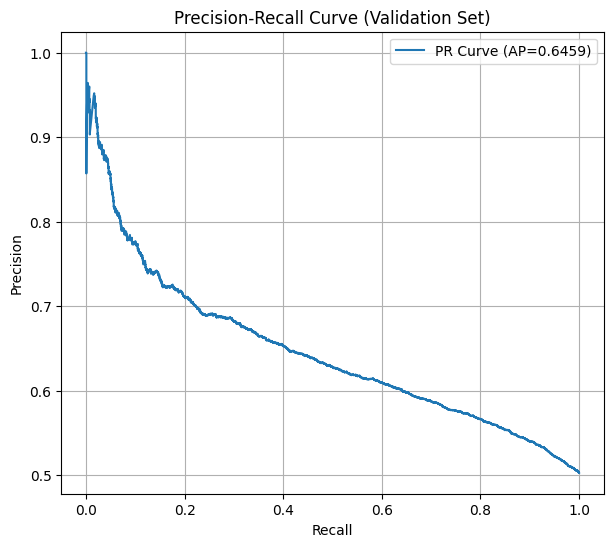

In [14]:
val_true = np.array(all_labels)
val_probs = np.array(val_probs)

precision, recall, thresholds = precision_recall_curve(val_true, val_probs)
ap = average_precision_score(val_true, val_probs)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)
print("\nValidation Average Precision (AP):", ap)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"PR Curve (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation Set)")
plt.grid(True)
plt.legend()
plt.show

In [15]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ProteinCNN(input_dim=x_test_tensor.shape[2])
model.load_state_dict(torch.load('best_cdrs_cnn_model.pth', map_location=DEVICE))
model.to(DEVICE)
model.eval()   # ← VERY IMPORTANT


C:\Users\ankit\AppData\Local\Temp\ipykernel_25780\3235038835.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_cdrs_cnn_model.pth', 

ProteinCNN(
  (conv1): Conv1d(22, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

C:\Users\ankit\AppData\Local\Temp\ipykernel_25780\27491131.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))



================ FULL TEST SET================

Accuracy:  0.592
Precision: 0.583
Recall:    0.654
F1:        0.617

Confusion matrix:
[[7438 6578]
 [4874 9207]]

ROC-AUC (full test):   0.633
PR-AUC (full test):    0.621


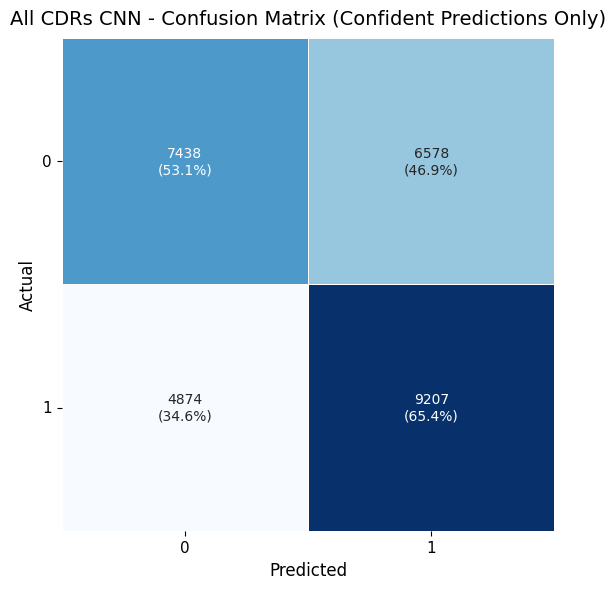

In [16]:
# Testing model
def plot_confmat_pretty(y_true, y_pred, labels=("0","1"), title="Confusion Matrix",
                        cmap="Blues", annotate_fontsize=11, tick_fontsize=11):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    # Row-normalized percentages (safer for class imbalance)
    with np.errstate(all='ignore'):
        cm_perc = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Build annotation with counts + perc
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            c = cm[i, j]
            p = cm_perc[i, j]
            annot[i, j] = f"{c}\n({0 if np.isnan(p) else p:.1f}%)"

    plt.figure(figsize=(6, 6))
    ax = sns.heatmap(
        cm, annot=annot, fmt="", cmap=cmap, cbar=False,
        xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor="white",
        square=True
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(title, fontsize=14, pad=10)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    # Keep y tick labels horizontal for readability
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
batch_size = 32
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# using saved model weights
model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))
model.eval()
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)

all_test_preds = []
all_test_labels = []
all_test_probs = []

with torch.no_grad():
    for x_batch, y_batch in tqdm(test_dataloader):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = np.argmax(logits.cpu().numpy(), axis=1)
        all_test_probs.extend(probs)
        all_test_preds.extend(preds)
        all_test_labels.extend(y_batch.cpu().numpy())

all_test_probs = np.array(all_test_probs)
all_test_labels = np.array(all_test_labels)

# Get test probabilities
y_scores_test = all_test_probs

y_pred_test = all_test_preds
clusters_test = test_df["Cluster_name"].to_numpy()
acc = accuracy_score(all_test_labels, all_test_preds)
prec = precision_score(all_test_labels, all_test_preds)
rec = recall_score(all_test_labels, all_test_preds)
f1 = f1_score(all_test_labels, all_test_preds)
cm = confusion_matrix(all_test_labels, all_test_preds)

roc_auc = roc_auc_score(all_test_labels, y_scores_test)
p, r, _ = precision_recall_curve(all_test_labels, y_scores_test)
pr_auc = auc(r, p)

print("\n================ FULL TEST SET================\n")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print("\nConfusion matrix:")
print(cm)
print(f"\nROC-AUC (full test):   {roc_auc:.3f}")
print(f"PR-AUC (full test):    {pr_auc:.3f}")

labels = ["0", "1"]
plot_confmat_pretty(
    all_test_labels,
    all_test_preds,
    labels=labels,
    title="All CDRs CNN - Confusion Matrix (Confident Predictions Only)"
)


In [17]:
print("\n================ Top-100 PREDICTIONS ONLY ================\n")
k =100
top_idx = np.argsort(-y_scores_test)[:k]
y_true_100 = all_test_labels[top_idx]
tp_100 = np.sum(all_test_labels[top_idx] == 1)
precision_100 = tp_100 / k
print(f"Precision@100: {precision_100:.3f}")
recall_100 = tp_100 / np.sum(all_test_labels== 1)
print(f"Recall@100: {recall_100:.3f}")
n = len(all_test_labels)
p = np.sum(all_test_labels == 1)
ef_100 = (tp_100/k)/(p/n)
print(f"EF@100: {ef_100:.3f}")
assert len(clusters_test) == len(all_test_labels)
diversity_100 = len(np.unique(clusters_test[top_idx]))
print(f"Diversity@100: {diversity_100}")
total_test_clusters = len(np.unique(clusters_test))
print("\nTotal clusters in test:", total_test_clusters)
normalized_diversity_100 = diversity_100 / total_test_clusters
print(f"Normalized diversity@100: {normalized_diversity_100:.3f}")
print("Top-K clusters:", np.unique(clusters_test[top_idx])[:10])

k1000 =1000
top1000_idx = np.argsort(-y_scores_test)[:k1000]
y_true_1000 = y_test[top1000_idx]
tp_1000 = np.sum(y_test[top1000_idx] == 1)
precision_1000 = tp_1000 / k1000
print(f"Precision@1000: {precision_1000:.3f}")


================ Top-100 PREDICTIONS ONLY ================

Precision@100: 0.820
Recall@100: 0.006
EF@100: 1.636
Diversity@100: 95

Total clusters in test: 26167
Normalized diversity@100: 0.004
Top-K clusters: [21167 24046 24898 25880 29851 35535 35815 42635 48178 50801]
Precision@1000: 0.741


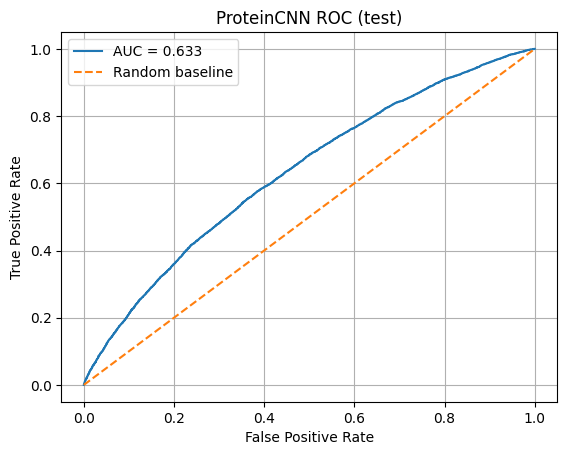

In [18]:
def plot_roc_cnn(model, dataloader, device, title="CNN ROC"):
    model.eval()
    y_true, y_score = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)                         # (B, 2)
            probs_pos = torch.softmax(logits, dim=1)[:, 1]

            y_true.extend(y.cpu().numpy())
            y_score.extend(probs_pos.cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return fpr, tpr, roc_auc

fpr, tpr, roc_auc = plot_roc_cnn(model, test_dataloader, device, title="ProteinCNN ROC (test)")

In [19]:
y_pred_test = np.asarray(y_pred_test)
y_true = np.asarray(all_test_labels).astype(int)
y_score = np.asarray(y_scores_test)
y_pred = np.asarray(y_pred_test).astype(int)
top100_df =  test_df.iloc[top_idx].copy()
top100_df["y_true"] = all_test_labels[top_idx]
top100_df["y_score"] = y_scores_test[top_idx]
top100_df["pred_label"] = y_pred_test[top_idx]


In [20]:
tp_top100_df = top100_df[
    (top100_df["y_true"] == 1) & (top100_df["pred_label"] == 1)
].copy()
tp_top100_df = tp_top100_df.rename(columns={"y_score": "pred_score"})

In [21]:
export_df = tp_top100_df[[
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]

In [22]:
export_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\Predictions\revised_cnn_all_cdrs_predictions.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))

Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 82


In [23]:

# ------------------------------------------------------------------
# 0.  Device and model (unchanged)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))
model.eval().to(device)

# ------------------------------------------------------------------
# 1.  Hook (unchanged)
conv1_activations, conv1_gradients = [], []

def forward_hook(module, _, output):
    conv1_activations.append(output.detach().cpu())
    output.register_hook(lambda g: conv1_gradients.append(g.detach().cpu()))

# clear any stale hooks and attach one fresh hook
for h in list(model.conv1._forward_hooks.values()):
    h.remove()
hook = model.conv1.register_forward_hook(forward_hook)

# ------------------------------------------------------------------
# 2.  Mini-batch loader (***only real addition***)
batch_size = 32                            # ↓ if you still OOM
top_test_X = x_test_tensor[top_idx]              # [k, L, V] (same representation as training)
top_ds = TensorDataset(top_test_X)
loader = DataLoader(top_ds, batch_size=batch_size, shuffle=False)

# accumulators for per-filter scores on CPU
C = model.conv1.out_channels #number of filters in first conv layer
global_sum = torch.zeros(C)
regional_sum = torch.zeros(C)
num_batches = 0
start_pos, end_pos = 10, 26                # region 10-25

# ------------------------------------------------------------------
# 3.  Loop over mini-batches
for (batch,) in loader:
    batch = batch.to(device).requires_grad_(True)

    # reset capture lists for this batch
    conv1_activations.clear()
    conv1_gradients.clear()

    output = model(batch)          # forward
    class1_logits = output[:, 1].sum()    # scalar objective
    model.zero_grad(set_to_none=True)
    class1_logits.backward()               # backward

    # analyse this batch
    act, grad = conv1_activations[0], conv1_gradients[0] # shapes : (batch_size, C, L) where L is sequence length
    global_sum   += (act * grad).mean(dim=(0, 2)) # mean over batch and sequence (one value per filter)
    regional_sum += (act[:, :, start_pos:end_pos] * grad[:, :, start_pos:end_pos]).mean(dim=(0, 2)) # same as above but only for region 10-25
    num_batches  += 1

   

# ------------------------------------------------------------------
# 4.  Final importance scores (mean across batches)
global_imp   = global_sum   / num_batches #averaging after summing them
regional_imp = regional_sum / num_batches

# ------------------------------------------------------------------
# 5.  Print results (unchanged)
top_g = global_imp.argsort(descending=True)
top_r = regional_imp.argsort(descending=True)

print("\nTop filters globally important for class 1:")
for i in range(10):
    idx = top_g[i].item()
    print(f"Filter {idx}: mean Grad×Act = {global_imp[idx]:.5f}")

print("\nTop filters important in region 10–26 for class 1:")
for i in range(10):
    idx = top_r[i].item()
    print(f"Filter {idx}: mean Grad×Act = {regional_imp[idx]:.5f}")

# ------------------------------------------------------------------



C:\Users\ankit\AppData\Local\Temp\ipykernel_25780\760743970.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))



Top filters globally important for class 1:
Filter 27: mean Grad×Act = 0.00380
Filter 13: mean Grad×Act = 0.00180
Filter 35: mean Grad×Act = 0.00163
Filter 48: mean Grad×Act = 0.00148
Filter 25: mean Grad×Act = 0.00128
Filter 38: mean Grad×Act = 0.00121
Filter 1: mean Grad×Act = 0.00110
Filter 44: mean Grad×Act = 0.00099
Filter 28: mean Grad×Act = 0.00082
Filter 20: mean Grad×Act = 0.00081

Top filters important in region 10–26 for class 1:
Filter 13: mean Grad×Act = 0.00296
Filter 48: mean Grad×Act = 0.00295
Filter 25: mean Grad×Act = 0.00167
Filter 28: mean Grad×Act = 0.00143
Filter 44: mean Grad×Act = 0.00135
Filter 1: mean Grad×Act = 0.00129
Filter 0: mean Grad×Act = 0.00108
Filter 18: mean Grad×Act = 0.00108
Filter 51: mean Grad×Act = 0.00107
Filter 61: mean Grad×Act = 0.00093


In [24]:
window_size = 5
motifs = []

model.eval()
device = next(model.parameters()).device
layer = model.conv1

try:
    filter_idx = top_r[0].item()
except Exception:
    filter_idx = 0
print("Studying conv1 filter", filter_idx)

conv1_activations.clear()
conv1_gradients.clear()

def fwd_hook(m, inp, out):
    conv1_activations.append(out)     # keep on device

def bwd_hook(m, gin, gout):
    conv1_gradients.append(gout[0])   # keep on device

hook = layer.register_forward_hook(fwd_hook)
hook_b = layer.register_full_backward_hook(bwd_hook)

with torch.enable_grad():
    for (batch_cpu,) in loader:
        # batch_cpu should be [B, L, V] from x_test_tensor[top_idx]
        batch = batch_cpu.to(device).requires_grad_(True)

        conv1_activations.clear()
        conv1_gradients.clear()

        output = model(batch)  # <-- if your model expects [B,V,L], use: model(batch.permute(0,2,1))
        class1_logits = output[:, 1].sum()
        model.zero_grad(set_to_none=True)
        class1_logits.backward()

        act = conv1_activations[0]                 # (B, C_out, L_out)
        activation_map = act[:, filter_idx, :].detach().cpu()  # (B, L_out)

        kprime = min(8, activation_map.size(1))
        vals, pos = torch.topk(torch.relu(activation_map), k=kprime, dim=1)

        batch_rows = torch.arange(activation_map.size(0)).repeat_interleave(kprime)
        seq_cols   = pos.reshape(-1)

        kconv = layer.kernel_size[0]
        p = layer.padding[0]
        s = layer.stride[0]
        half = window_size // 2
        L_in = batch_cpu.size(1)

        for b, j in zip(batch_rows.tolist(), seq_cols.tolist()):
            start_rf = j * s - p
            center   = start_rf + (kconv // 2)

            start = max(0, min(center - half, L_in - window_size))
            end   = start + window_size

            win = batch_cpu[b, start:end, :].float().contiguous()  # [W, V]
            motifs.append(win.detach().numpy())

hook.remove()
hook_b.remove()
conv1_activations.clear()
conv1_gradients.clear()

print("len(motifs):", len(motifs))
if motifs:
    print("motifs[0] shape:", motifs[0].shape)


Studying conv1 filter 13
len(motifs): 800
motifs[0] shape: (5, 22)


In [25]:
aa_list = "ACDEFGHIKLMNPQRSTVWY-"
idx_to_aa = {i: aa for i, aa in enumerate(aa_list)}

def decode_one_hot(window):
    return "".join([idx_to_aa[np.argmax(pos)] for pos in window])

decoded_motifs = [decode_one_hot(m) for m in motifs]
print("Top motif-like patterns activating conv1 filter", filter_idx)

seen = set()
unique_decoded = []
for m in decoded_motifs:
    if m not in seen:
        seen.add(m)
        unique_decoded.append(m)
for i, motif in enumerate(unique_decoded[:10], 1):
    print(f"{i}. {motif}")


Top motif-like patterns activating conv1 filter 13
1. AAKRY
2. TAAKR
3. -GTTA
4. AKRYG
5. GSIS-
6. -SYVY
7. --PRG
8. VSRRI
9. RRINS
10. -GYRH


In [26]:
from collections import Counter

#Count occurances of each decoded motif
motif_counter = Counter(decoded_motifs)

#show most common motifs
print(f"\nTop motif-like patterns activating conv1 filter {filter_idx}\n")
for motif, count in motif_counter.most_common(20):
    print(f"{motif}: {count} times")


Top motif-like patterns activating conv1 filter 13

GSIS-: 47 times
GNIS-: 36 times
-GTTA: 21 times
GTIS-: 17 times
-ATTA: 11 times
TAARY: 9 times
-GITA: 8 times
GYIS-: 7 times
-STTA: 7 times
TAARR: 7 times
---RR: 7 times
-GSTA: 5 times
--AST: 5 times
--ATT: 5 times
TAAKR: 4 times
TAAYR: 4 times
TKKHY: 4 times
TAANV: 4 times
KKHYY: 4 times
-AITA: 4 times


In [27]:
# Must match your amino-acid order (incl. '-' gap)
from matplotlib.colors import TwoSlopeNorm
AA_ORDER = "ACDEFGHIKLMNPQRSTVWY-"
AA_TO_IDX = {aa:i for i,aa in enumerate(AA_ORDER)}
V = len(AA_ORDER)

def onehot_from_seq(seq):
    """[L, V] one-hot for a CDR string (may contain '-')."""
    device = next(model.parameters()).device
    L = len(seq)
    X = torch.zeros(L, V, dtype=torch.float32, device=device)
    for i, ch in enumerate(seq):
        X[i, AA_TO_IDX.get(ch, AA_TO_IDX['-'])] = 1.0
    return X

def build_region_spans_for_row(row):
    """Return dict region -> list of (start,end) for the concatenated CDRs."""
    c1 = str(row["CDR1 aligned"]); c2 = str(row["CDR2 aligned"]); c3 = str(row["CDR3 aligned"])
    l1, l2, l3 = len(c1), len(c2), len(c3)
    spans = {
        "CDR1": [(0, l1-1)] if l1>0 else [],
        "CDR2": [(l1, l1+l2-1)] if l2>0 else [],
        "CDR3": [(l1+l2, l1+l2+l3-1)] if l3>0 else [],
    }
    spans["ALL"] = [(0, l1+l2+l3-1)]
    return spans

def reduce_importance(attr, mode="L1"):
    # attr: [..., V] residue-channel attributions
    if mode == "L1":
        return attr.abs().sum(dim=-1)
    elif mode == "L2":
        return (attr**2).sum(dim=-1).sqrt()
    elif mode == "max":
        return attr.abs().amax(dim=-1)
    else:
        raise ValueError("mode must be L1|L2|max")

def safe_mean(x, mask):
    # x, mask: [B, L] -> mean over True positions per sequence
    num = (x * mask).sum(dim=-1)
    den = mask.sum(dim=-1).clamp_min(1)
    return num / den

def per_cdr_importance_from_attr(attr_BLV, region_spans_per_seq, reduce_mode="L1"):
    """
    attr_BLV: [B,L,V] residue-channel attributions
    region_spans_per_seq: list (len B) of dicts from build_region_spans_for_row
    """
    B, L, V = attr_BLV.shape
    imp_BL = reduce_importance(attr_BLV, reduce_mode)  # [B,L]
    results = {}

    region_names = ["CDR1","CDR2","CDR3"]
    masks = {name: torch.zeros((B,L), dtype=torch.bool, device=attr_BLV.device) for name in region_names}
    for b in range(B):
        spans = region_spans_per_seq[b]
        for name in region_names:
            for s,e in spans.get(name, []):
                masks[name][b, s:e+1] = True

    for name in region_names:
        per_seq_means = safe_mean(imp_BL, masks[name])  # [B]
        mu = per_seq_means.mean().item()
        results[name] = {"mean": mu}
    return results

def plot_cdr_bars(results, title="Per-CDR importance", palette="Set2"):
    names = list(results.keys())
    means = [results[k]["mean"] for k in names]
    cmap = plt.get_cmap(palette)
    colors = [cmap(i) for i in np.linspace(0, 1, len(names))]
    bars = plt.bar(names, means, color=colors, edgecolor="black", linewidth=1)
    plt.ylabel("Importance (mean per token)")
    plt.title(title)
    # annotate values
    #for b, v in zip(bars, means):
        #plt.text(b.get_x() + b.get_width()/2, b.get_height()*1.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

def residue_heatmap_matrix(attr_LV, normalize="pos", clip=None):
    """Normalize per-position by default to highlight AA preferences at each site."""
    A = attr_LV.clone().detach()
    if normalize == "pos":
        denom = A.abs().sum(dim=-1, keepdim=True).clamp_min(1e-8)
        A = A / denom
    elif normalize == "global":
        mu = A.mean()
        sd = A.std(unbiased=False).clamp_min(1e-8)
        A = (A - mu) / sd
    if clip is not None:
        A = A.clamp(-clip, clip)
    return A.detach().cpu().numpy()

def show_residue_heatmap(H, pos_labels=None, aa_labels=AA_ORDER, title="Residue heatmap", cmap_pos = "viridis", cmap_signed = "RdBu_r"):
    H = np.asarray(H)
    has_neg = np.nanmin(H) < 0 and np.nanmax(H) > 0

    if has_neg:
        norm = TwoSlopeNorm(vmin=float(np.nanmin(H)), vcenter=0.0, vmax=float(np.nanmax(H)))
        cmap = cmap_signed
    else:
        norm = None
        cmap = cmap_pos

    plt.figure()
    im = plt.imshow(H, aspect='auto', cmap=cmap, norm=norm)
    plt.xlabel("Amino acid")
    plt.ylabel("Position")
    plt.title(title)
    L, V = H.shape
    if aa_labels is not None:
        plt.xticks(ticks=np.arange(V), labels=list(aa_labels), rotation=0)
    if pos_labels is not None:
        plt.yticks(ticks=np.arange(L), labels=pos_labels)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

def saliency_grad_times_input(model, X_BLV, target_class=None):
    """
    Gradient×Input saliency on residue one-hot channels.
    X_BLV: [B,L,V] float, requires_grad set inside.
    target_class: int or None (None -> use argmax per sample)
    Returns: attr [B,L,V]
    """
    model.eval()
    X = X_BLV.clone().detach().requires_grad_(True)
    logits = model(X)  # [B,C]
    if target_class is None:
        y = logits.argmax(dim=-1)
    else:
        y = torch.full((X.shape[0],), int(target_class), dtype=torch.long, device=logits.device)
    scores = logits.gather(1, y.view(-1,1)).sum()
    model.zero_grad(set_to_none=True)
    scores.backward()
    attr = X.grad * X  # grad × input
    return attr

def build_batch_from_dataframe(df, device=None):
    """Create [B,L,V] one-hot batch from df['CDRs'] (concatenated CDR1+CDR2+CDR3)."""
    device = device or next(model.parameters()).device
    seqs = list(df["CDRs"].astype(str).values)
    L = len(seqs[0])
    X = torch.zeros((len(seqs), L, V), dtype=torch.float32, device=device)
    for b, s in enumerate(seqs):
        X[b] = onehot_from_seq(s)
    return X

def build_region_spans_for_dataframe(df):
    return [build_region_spans_for_row(row) for _, row in df.iterrows()]


C:\Users\ankit\AppData\Local\Temp\ipykernel_25780\724084601.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))


Total test samples: 28097
Top - 100: 100


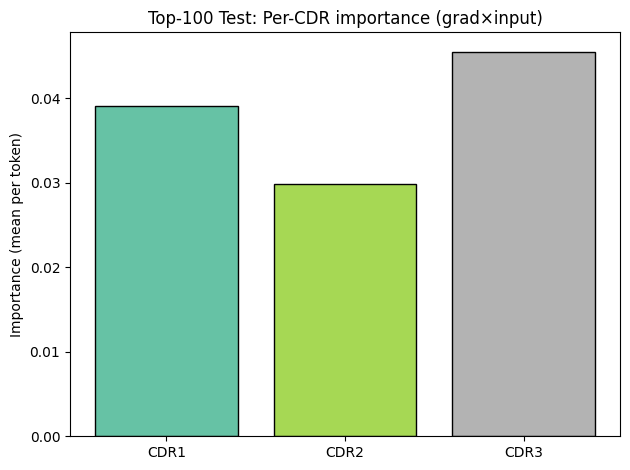

In [28]:
# (Optional) reload your best model weights
# model = ProteinCNN().to(device)
# model.load_state_dict(torch.load('cdrs_cnn_model.pth', map_location=device))
# using saved model weights
model.load_state_dict(torch.load('best_cdrs_cnn_model.pth'))
model.eval()
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)

# 1) Build inputs + CDR spans from test set
test_X = x_test_tensor.to(next(model.parameters()).device)   # [B, L, V]
test_region_spans = build_region_spans_for_dataframe(test_df)

# -----------------------------
# NEW: restrict to confident set
# -----------------------------
# 'mask' and 'y_pred_test' were created in Cell 18:
# mask = (y_pred_test != -1)   # numpy bool array of length B

conf_indices = top_idx   # indices of confident predictions

print(f"Total test samples: {test_X.shape[0]}")
print(f"Top - 100: {len(conf_indices)}")

if len(conf_indices) == 0:
    print("No confident samples found. Did you set thr_pos/thr_neg too strict?")
else:
    # Select only confident samples
    # (convert to list so it's safe for PyTorch indexing)
    conf_idx_list = conf_indices.tolist()

    conf_test_X = test_X[conf_idx_list]   # [B_conf, L, V]
    conf_test_region_spans = [test_region_spans[i] for i in conf_idx_list]

    # If test is big, compute saliency in batches to save memory
    def saliency_batched(model, X_BLV, batch_size=128, target_class=None):
        B, L, V = X_BLV.shape
        out = torch.zeros_like(X_BLV)
        for start in range(0, B, batch_size):
            end = min(B, start + batch_size)
            out[start:end] = saliency_grad_times_input(
                model, X_BLV[start:end], target_class=target_class
            )
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        return out

    # 2) Saliency (grad×input) on residue channels for CONFIDENT subset
    attr_conf = saliency_batched(
        model,
        conf_test_X,
        batch_size=16,
        target_class=None          # None → uses predicted class inside your saliency fn
    )                               # [B_conf, L, 21]
    attr_conf_aa = attr_conf[..., :21]  # [B_conf, L, 21]

    # 3) Per-CDR importance bars on CONFIDENT subset (with 95% bootstrap CIs)
    conf_bars = per_cdr_importance_from_attr(
        attr_conf,
        conf_test_region_spans,
        reduce_mode="L1"
    )
    plot_cdr_bars(
        conf_bars,
        title="Top-100 Test: Per-CDR importance (grad×input)"
    )
